# Biodiversity in National Parks

## Task 1: Load the Data

In [566]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [567]:
# Load datasets
species_info = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

## Task 2: Project Scoping
**Goals**
* Interpret data from the National Parks Service about endangered species in different parks.
* Investigate patterns in the types of endangered species.

**Steps**
1. Clean both datasets. If there is missing data, remove or replace it. If there are duplicates (i.e. species), remove them.
2. Combine them so that we know where each animal (based on its common and scientific names) lives and what their conservation status is.
3. Plot data based on conservation status, park name, and so on.

## Task 3: Explore and Explain Data

### Previewing Raw Datasets

In [568]:
# Get a preview of different species and their conservation status
print('Here\'s a preview of the species dataset:')
print(species_info.head(10))

Here's a preview of the species dataset:
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   
5   Mammal         Odocoileus virginianus   
6   Mammal                     Sus scrofa   
7   Mammal                  Canis latrans   
8   Mammal                    Canis lupus   
9   Mammal                    Canis rufus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
5            

**Observation:** Judging by the above preview, the majority of species do not have a documented conservation status. This missing data is not to be treated as MCAR, MAR, or MNAR because they do not appear to represent failed observations. Instead, they function as a structural missing value -- species without a listed conservation designation.

In [569]:
# Get a preview of recorded sightings of different species at several national parks for the past 7 days
print('And here\'s a preview of the observations dataset:')
print(observations.head(10)) # contains recorded sightings 

And here's a preview of the observations dataset:
                     scientific_name                            park_name  \
0                 Vicia benghalensis  Great Smoky Mountains National Park   
1                     Neovison vison  Great Smoky Mountains National Park   
2                  Prunus subcordata               Yosemite National Park   
3               Abutilon theophrasti                  Bryce National Park   
4           Githopsis specularioides  Great Smoky Mountains National Park   
5  Elymus virginicus var. virginicus               Yosemite National Park   
6                   Spizella pusilla            Yellowstone National Park   
7                  Elymus multisetus  Great Smoky Mountains National Park   
8             Lysimachia quadrifolia               Yosemite National Park   
9         Diphyscium cumberlandianum            Yellowstone National Park   

   observations  
0            68  
1            77  
2           138  
3            84  
4           

**Observation:** This preview does not contain missing data. However, this does not necessarily mean that the observations data is complete or free of duplicates.

### Cleaning Data

In [570]:
# Find missing data
print('Missing values in the species dataset:')
print(species_info.isna().sum())
print('\nMissing values in the observations dataset:')
print(observations.isna().sum())

Missing values in the species dataset:
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64

Missing values in the observations dataset:
scientific_name    0
park_name          0
observations       0
dtype: int64


**Observation:** The observations dataset has no missing values, so the species dataset should be the one to get the replacement treatment (particularly the conservation statuses).

In [571]:
# Finding duplicates
print('Duplicate values in the species dataset:', species_info.duplicated(subset=['scientific_name', 'common_names']).sum())
print('Duplicate values in the observations dataset:', observations.duplicated(subset=['scientific_name', 'park_name']).sum())

Duplicate values in the species dataset: 2
Duplicate values in the observations dataset: 1132


**Observation:** Duplicate values are present in both datasets, but there are significantly more in the observations dataset. This means some species were recorded more than once in the same park.

In [572]:
# Replace missing values
species_info['conservation_status'] = species_info['conservation_status'].fillna('Not Listed')

In [573]:
# Remove duplicates
species_info = species_info.drop_duplicates(subset=['scientific_name'])
#observations = observations.groupby(['scientific_name', 'park_name'], as_index=False)['observations'].sum()
observations = observations.drop_duplicates(subset=['scientific_name', 'park_name'])

### Graphing Data

#### Which species were spotted the most at each park?

In [574]:
observations['scientific_name'].unique() # first, check whether the species can feasibly be graphed

array(['Vicia benghalensis', 'Neovison vison', 'Prunus subcordata', ...,
       'Ranunculus hebecarpus', 'Gulo gulo', 'Dichanthelium depauperatum'],
      shape=(5541,), dtype=object)

Considering there are over 5,000 species in the dataset, plotting the top 10 per park would suffice.

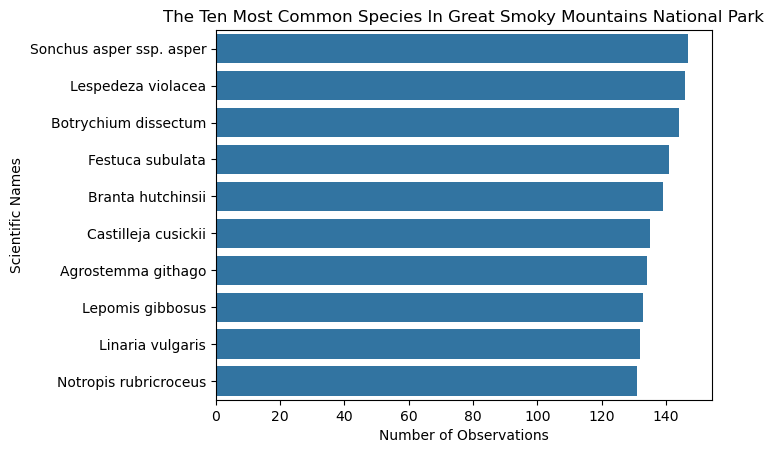

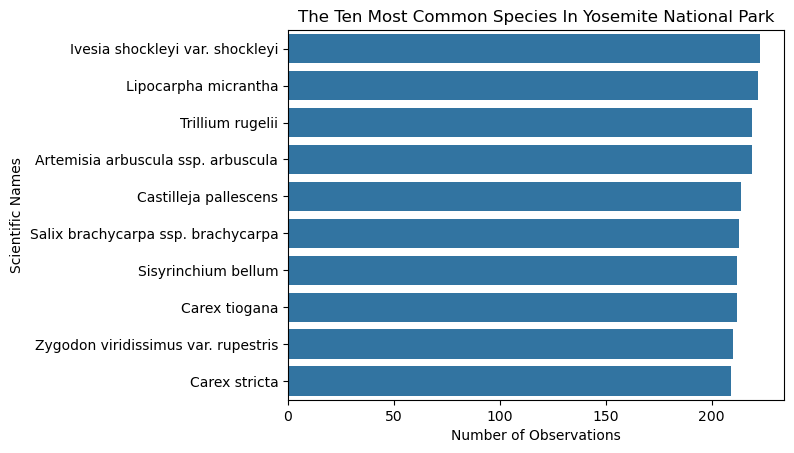

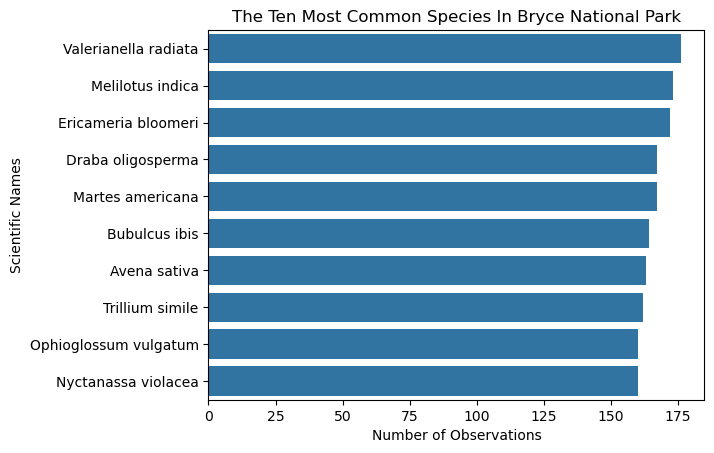

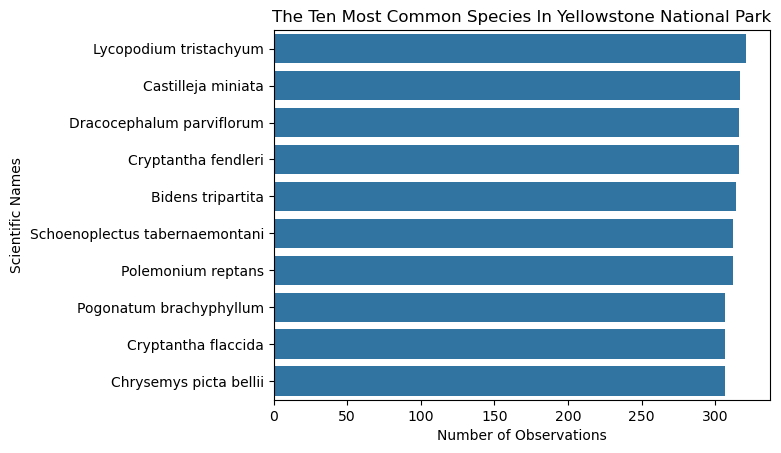

In [575]:
parks = observations['park_name'].unique() # helps separate each graph with respect to park name
for park in parks:
    top_ten_species = observations[observations['park_name']==park].nlargest(10, 'observations')
    sns.barplot(data=top_ten_species, x='observations', y='scientific_name')
    plt.xlabel('Number of Observations')
    plt.ylabel('Scientific Names')
    plt.title(f'The Ten Most Common Species In {park}')
    plt.savefig(f'{park}_species.png')
    plt.show()

**Observation:** Yellowstone National Park has the highest number of sightings among the ten most observed species, while Great Smoky Mountains National Park has the lowest. Although this does not necessarily imply the former has the highest biodiversity, it suggests two possibilities -- either Yellowstone National Park is larger than the other parks, or sampling was more rigorous there.

### How are animals' conservation statuses distributed?

In [576]:
# Separate animals from plants -- the former includes mammals, birds, reptiles, amphibians, and fish
animal_categories = ['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish']
is_animal = species_info['category'].isin(animal_categories)
animals = species_info[is_animal]

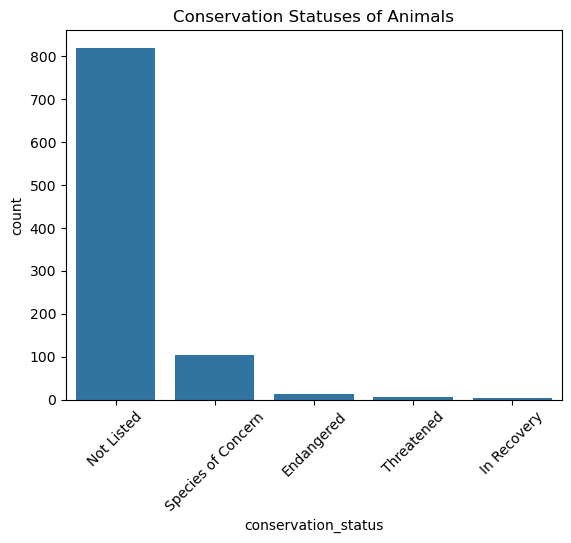

In [577]:
# Count the number of occurrences in each conservation status
sns.countplot(data=animals, x='conservation_status', order=animals['conservation_status'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Conservation Statuses of Animals')
plt.savefig('conservation_status.png')
plt.show()

**Observations**
* The majority of animals in this dataset are not listed, and only a few are documented as endangered or even threatened. This, however, does not guarantee that the undocumented animals are safe from harm.
* In fact, it's hard to tell at a glance what animal categories are most at risk or in recovery. Another graph -- one that depicts all listed animals -- will provide a better picture.

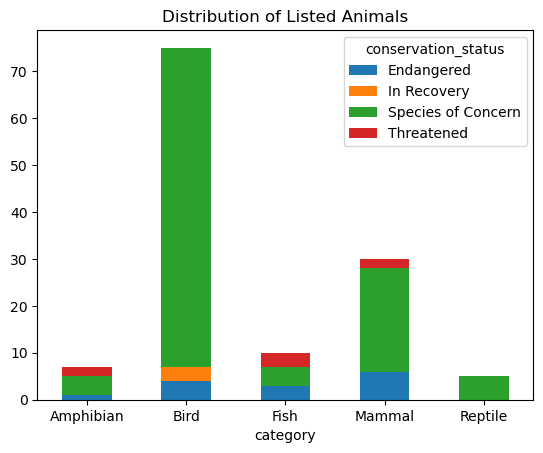

In [578]:
# Now graph all animals that were listed
listed_animals = animals[animals['conservation_status']!='Not Listed']
listed_plot = pd.crosstab(listed_animals['category'], listed_animals['conservation_status'])
listed_plot.plot(kind='bar', stacked=True)
plt.title('Distribution of Listed Animals')
plt.xticks(rotation=0)
plt.savefig('listed_animal_distributions.png')
plt.show()

**Observations**
* 'Species of Concern' is the most common listed status across all animal categories. However, it is prominent for both birds and mammals.
* Not only that, but birds and mammals are the only categories with animals 'In Recovery'.
* 'Species of Concern' is the only listed status shared by reptiles.
* Fish are the most threatened. Although the graph alone does not provide the reasons, it is plausible that water pollution and overfishing are responsible for this.

### Which species are most at risk?

In [579]:
species_categories = species_info['category'].unique()

In [580]:
# Species that are most at risk are endangered or threatened
at_risk_categories = ['Endangered', 'Threatened']
is_at_risk = species_info['conservation_status'].isin(at_risk_categories)
at_risk_species = species_info[is_at_risk]

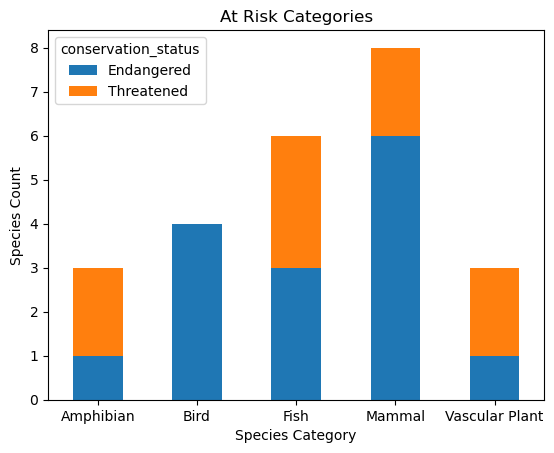

In [581]:
risk_table = pd.crosstab(at_risk_species['category'], at_risk_species['conservation_status'])
risk_table.plot(kind='bar', stacked=True)
plt.title('At Risk Categories')
plt.xlabel('Species Category')
plt.ylabel('Species Count')
plt.xticks(rotation=0)
plt.savefig('at_risk.png')
plt.show()

**Observations**
* All birds at risk are endangered, meaning they are already at risk of extinction.
* Mammals have the highest raw count of at-risk species -- six are already endangered and two threatened.
* There are no non-vascular plants at risk. This, however, does not guarantee that they are safe.

In [582]:
at_risk_observations = observations.merge(at_risk_species, on='scientific_name')
species_sightings = at_risk_observations.groupby(['common_names', 'conservation_status', 'category'], as_index=False)['observations'].sum()

In [583]:
is_threatened = species_sightings['conservation_status']=='Threatened'
print('The following species are classified as threatened:')
all_threatened_species = species_sightings[is_threatened]
print(all_threatened_species[['category', 'common_names']].sort_values(by='category'))

The following species are classified as threatened:
          category                              common_names
2        Amphibian                California Red-Legged Frog
23       Amphibian                             Yosemite Toad
10            Fish                  Lahontan Cutthroat Trout
19            Fish                              Spotfin Chub
22            Fish                          Yellowfin Madtom
7           Mammal                              Grizzly Bear
12          Mammal  Northern Long-Eared Bat, Northern Myotis
17  Vascular Plant                     Small Whorled Pogonia
20  Vascular Plant                          Virginia Spiraea


In [584]:
is_endangered = species_sightings['conservation_status']=='Endangered'
print('The following species are classified as endangered:')
all_endangered_species = species_sightings[is_endangered]
print(all_endangered_species[['category', 'common_names']].sort_values(by='category'))

The following species are classified as endangered:
          category                                       common_names
16       Amphibian                   Sierra Nevada Yellow-Legged Frog
0             Bird          Bachman's Warbler, Bachman's Wood Warbler
1             Bird                                  California Condor
14            Bird                            Red-Cockaded Woodpecker
21            Bird                                     Whooping Crane
4             Fish                                   Duskytail Darter
9             Fish                                        June Sucker
18            Fish                                       Smoky Madtom
3           Mammal  Carolina Northern Flying Squirrel, Northern Fl...
5           Mammal                                        Gray Myotis
6           Mammal                                          Gray Wolf
8           Mammal              Indiana Bat, Indiana Or Social Myotis
13          Mammal                    

**Explanation:** The tables above indicate which species are threatened and which are endangered. The category counts work alongside the stacked bar graph above to show how many belong to each conservation status.

### Are the differences between species and their conservation status significant?
The contingency table below will demonstrate whether there is a significant difference between the type of living thing and whether it is endangered or threatened.

In [585]:
listed_species = species_info[species_info['conservation_status']!='Not Listed']

In [586]:
# Species
species_info['species_type'] = np.where(species_info['category'].isin(animal_categories), 'Animal', 'Plant')

In [587]:
# At risk
species_info['is_at_risk'] = species_info['conservation_status'].isin(['Endangered', 'Threatened'])

In [588]:
# Checking for statistical significance
conservation_contingency = pd.crosstab(species_info['species_type'], species_info['is_at_risk'])
print('Contingency table:')
print(conservation_contingency)
chi2_stat, p_value, dof, expected = chi2_contingency(conservation_contingency)
print('Checking whether species or at-risk status are independent variables ...')
print('- Chi-squared statistic:', chi2_stat)
print('- p-value:', p_value)
print('- Expected frequencies:\n', expected)

Contingency table:
is_at_risk    False  True 
species_type              
Animal          925     21
Plant          4592      3
Checking whether species or at-risk status are independent variables ...
- Chi-squared statistic: 79.52359976312025
- p-value: 4.764995109047095e-19
- Expected frequencies:
 [[9.41902545e+02 4.09745533e+00]
 [4.57509746e+03 1.99025447e+01]]


**Observations**
* The p-value is practically zero, meaning the species dataset has a statistically significant association between species type and at-risk status.
* In fact, the contingency table showed that animals are proportionally more likely to be classified as at risk than plants.
* Conversely, plants are proportionally more likely to not be classified as at risk than animals. However, because an earlier graph showed most species in the respective dataset were not listed, 'not at risk' does not necessarily mean safe.

## Task 4: Conclusions
First of all, animals in these datasets are more likely than plants to be classified as at risk (e.g. endangered, threatened). Of them, mammals have the largest raw number of at-risk species. Second, observation totals vary considerably among parks, with Yellowstone National Park boasting the highest number. However, without information about park side or rigour in sampling, it is impossible to feasibly gauge observation totals as biodiversity metrics. Not only that, but every park has a different species that was observed the most, meaning recorded abundance varies geographically.